In [1]:
print('hello world')

hello world


In [5]:
import pandas as pd
df=pd.read_csv(r'D:\projects\analisis\data\ecommerce_transactions_50000.csv',parse_dates=['order_date'])

In [11]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          50000 non-null  int64         
 1   customer_id       50000 non-null  int64         
 2   order_date        50000 non-null  datetime64[ns]
 3   product_category  50000 non-null  object        
 4   price             50000 non-null  float64       
 5   quantity          50000 non-null  int64         
 6   payment_method    50000 non-null  object        
 7   region            50000 non-null  object        
 8   revenue           50000 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 3.4+ MB


,order_id,customer_id,order_date,product_category,price,quantity,payment_method,region,revenue
0,1,4174,2024-11-04,Clothing,453.84,2,Bank Transfer,Kalimantan,907.68
1,2,4507,2024-02-10,Clothing,460.26,3,Bank Transfer,Sulawesi,1380.78
2,3,1860,2024-05-06,Clothing,34.76,4,Credit Card,Sumatra,139.04
3,4,2294,2024-10-19,Electronics,317.78,1,Credit Card,Sumatra,317.78
4,5,2130,2024-09-10,Clothing,399.21,4,Bank Transfer,Bali,1596.84


In [14]:
df.shape

(50000, 9)

In [18]:
# reveneue per kategori product
df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)

product_category
Clothing       7886179.09
Electronics    7878034.56
Home           6300120.01
Sports         4775043.97
Books          4613083.51
Name: revenue, dtype: float64

In [29]:
# revenue per wilayah
df.groupby('region')['revenue'].sum().sort_values(ascending=False)

region
Java          6326934.24
Kalimantan    6311714.35
Sumatra       6292274.06
Bali          6280710.62
Sulawesi      6240827.87
Name: revenue, dtype: float64

In [34]:
# revenue per payment method
df.groupby('payment_method')['revenue'].sum().sort_values(ascending=False)

payment_method
E-Wallet         10550180.68
Credit Card      10478551.29
Bank Transfer    10423729.17
Name: revenue, dtype: float64

In [41]:
# trend transaksi per bulan
df.groupby(df['order_date'].dt.to_period('M'))['revenue'].sum().sort_index()

order_date
2024-01    2662925.83
2024-02    2557700.38
2024-03    2672536.19
2024-04    2557822.97
2024-05    2689443.88
2024-06    2566098.84
2024-07    2639998.11
2024-08    2661783.92
2024-09    2592772.82
2024-10    2652030.80
2024-11    2612731.88
2024-12    2586615.52
Freq: M, Name: revenue, dtype: float64

<Axes: xlabel='order_date'>

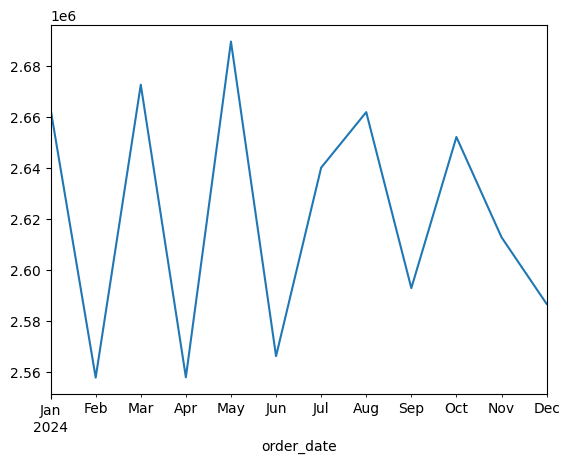

In [43]:
df.groupby(df['order_date'].dt.to_period('M'))['revenue'].sum().sort_index().plot()